In [1]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import cohen_kappa_score, classification_report, confusion_matrix, roc_auc_score
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import cohen_kappa_score, roc_auc_score
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

/Users/josephineamponsah/Documents/credit-scoring-nlp-dl/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_dl = pd.read_csv('data/data_dl.csv')

In [3]:
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [4]:
num_cols = data_dl.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = data_dl.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

In [5]:
cat_cols.remove('Target')
cat_cols

['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

In [6]:
# Ordinal encoding — preserve the natural order
label_map = {"Poor": 0, "Standard": 1, "Good": 2}
data_dl["Target_label"] = data_dl["Target"].map(label_map)

In [7]:
data_dl[data_dl.isnull().any(axis=1)]

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,month3_balance,month3_credit_util,month3_delayed_payment,month3_delay_from_due_date,max_delayed_payment,max_credit_util,credit_util_var,balance_m1_m2,balance_m2_m3,Target_label
3,55,Entrepreneur,30689.89,2612.490833,2,5,4,100,4,9.0,...,419.880784,27.445422,6.0,5,9.0,41.154317,34.213323,-0.145042,0.056371,1
5,31,Lawyer,73928.46,5988.705000,4,5,8,0,8,7.0,...,633.080175,35.275437,7.0,7,10.0,42.769864,32.667415,0.560140,-0.193844,2
8,24,Doctor,114838.41,9843.867500,2,5,7,3,11,11.0,...,491.113388,26.114214,14.0,13,14.0,35.141567,9.717689,-0.061997,0.612714,1
9,45,Journalist,31370.80,NaN,1,6,12,2,-2,2.0,...,378.189779,25.502469,0.0,1,2.0,37.565053,20.705851,-0.190363,-0.107558,2
11,33,Engineer,88640.24,7266.686667,3,6,1,2,-1,NaN,...,195.369079,38.323639,0.0,4,2.0,41.036168,25.202502,0.098338,2.416203,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12490,38,Media_Manager,139664.96,11777.746667,3,6,12,4,14,12.0,...,182.547539,27.714375,12.0,14,12.0,40.171095,22.103331,NaN,2.482677,2
12492,48,_______,22620.79,NaN,6,2,9,0,27,15.0,...,254.733128,27.699504,18.0,27,19.0,37.450793,18.993999,-0.350503,0.553290,0
12495,19,Lawyer,42903.79,3468.315833,0,4,6,1,9,NaN,...,394.500158,35.549456,-1.0,14,0.0,35.716618,19.951316,0.272631,-0.110311,2
12496,45,Media_Manager,16680.35,NaN,1,1,5,4,1,0.0,...,233.301539,24.972853,NaN,1,0.0,41.212367,27.790639,-0.087474,0.460277,2


In [8]:
target_cols = ['Target_label']

In [9]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight= 'balanced',
    classes=np.array([0, 1, 2]),
    y=data_dl["Target_label"].values
)
class_weights = torch.tensor(class_weights, dtype=torch.float32)
# Pass into loss function — model pays more attention to rare classes
criterion = nn.CrossEntropyLoss(weight=class_weights)

In [10]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [11]:
def null_fix(df):
    for col in df.columns:
        if col == "Monthly_Inhand_Salary" and df[col].isnull().any():
            df[col] = df['Annual_Income'] / 12
        elif df[col].isnull().any():
            df[col].fillna(0, inplace=True)
    return df

In [12]:
data_dl = data_dl.pipe(null_fix)

/var/folders/3f/9mw8q0xn58v4947ln1hhc4mr0000gn/T/ipykernel_61170/904450771.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(0, inplace=True)


In [13]:
X_train, X_test , y_train , y_test = train_test_split(
    data_dl.drop(columns=target_cols),
    data_dl[target_cols],
    test_size=0.25,
    random_state=42,
    stratify=data_dl[target_cols]
)

In [14]:
print("Checking for NaN in training data...")
print(f"NaN in X_train: {X_train.isnull().sum().sum()}")
print(f"NaN in X_test: {X_test.isnull().sum().sum()}")
if X_train.isnull().any().any():
    print("\nColumns with NaN in train set:")
    print(X_train.isnull().sum()[X_train.isnull().sum() > 0])
    # Fill NaN with median for numeric, mode for categorical
    for col in num_cols:
        if X_train[col].isnull().any():
            X_train[col].fillna(X_train[col].median(), inplace=True)
            X_test[col].fillna(X_test[col].median(), inplace=True)
    for col in cat_cols:
        if X_train[col].isnull().any():
            X_train[col].fillna(X_train[col].mode()[0] if len(X_train[col].mode()) > 0 else "Unknown", inplace=True)
            X_test[col].fillna(X_test[col].mode()[0] if len(X_test[col].mode()) > 0 else "Unknown", inplace=True)
    print("NaN values filled.")

Checking for NaN in training data...
NaN in X_train: 0
NaN in X_test: 0


In [15]:
X_train.head()

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,month2_delay_from_due_date,month3_balance,month3_credit_util,month3_delayed_payment,month3_delay_from_due_date,max_delayed_payment,max_credit_util,credit_util_var,balance_m1_m2,balance_m2_m3
3738,40,Musician,20877.19,1739.765833,7,6,20,5,20,20.0,...,20,292.372613,38.528879,17.0,17,21.0,38.528879,20.849362,-0.227512,0.040113
7274,40,Accountant,60015.00,5001.250000,7,7,24,2,14,0.0,...,14,542.316098,27.364181,12.0,14,18.0,39.142384,32.646463,0.555936,-0.299054
4810,29,Writer,19220.61,1601.717500,6,7,30,100,43,22.0,...,43,202.294673,33.173982,22.0,47,24.0,40.270504,30.038507,-0.123344,0.502679
121,37,Journalist,18717.02,1559.751667,8,5,15,5,4,18.0,...,7,274.900823,31.583289,16.0,9,20.0,33.813130,8.082557,0.056698,0.005579
603,33,Architect,122942.28,10245.190000,2,3,3,1,8,4.0,...,8,831.347622,32.334353,4.0,8,5.0,41.735281,17.316611,-0.638297,0.254215


In [16]:
label_encoder = LabelEncoder().fit(data_dl[cat_cols].values.ravel())
scaler = StandardScaler().fit(X_train[num_cols])

In [17]:
y = y_train['Target_label'].astype('category')

In [18]:
# Train one encoder per categorical column
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    le.fit(data_dl[col].astype(str))         # fit on full data
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col]  = le.transform(X_test[col].astype(str))
    le_dict[col] = le

# Now calculate cat_dims correctly
cat_dims = []
for col in cat_cols:
    vocab_size = len(le_dict[col].classes_) + 2 
    embedding_dim = min(8, (vocab_size + 1) // 2)
    cat_dims.append((vocab_size, embedding_dim))

print("cat_dims:", cat_dims)

cat_dims: [(18, 8), (6, 3), (5, 3), (9, 5)]


In [19]:
le_dict

{'Occupation': LabelEncoder(),
 'Credit_Mix': LabelEncoder(),
 'Payment_of_Min_Amount': LabelEncoder(),
 'Payment_Behaviour': LabelEncoder()}

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

In [21]:
class HistDataset(Dataset):
    def __init__(self, X, y, cat_cols, num_cols):
        # X already has integer-encoded cat columns — no re-encoding needed
        self.cat = torch.tensor(X[cat_cols].values, dtype=torch.long)
        self.num = torch.tensor(X[num_cols].values, dtype=torch.float32)
        y_vals = y.values.ravel() if hasattr(y, 'values') else np.array(y).ravel()
        self.y  = torch.tensor(y_vals, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.cat[idx], self.num[idx], self.y[idx]

In [22]:
# print(X_train[cat_cols].head()) 

In [23]:
train_set = HistDataset(X_train, y_train, cat_cols, num_cols)
val_set = HistDataset(X_test, y_test, cat_cols, num_cols)

In [24]:
# sample_weights = class_weights[y_train['Target_label'].values]

# sampler = torch.utils.data.WeightedRandomSampler(
#     weights=sample_weights,
#     num_samples=len(sample_weights),
#     replacement=True
# )

# train_loader = DataLoader(train_set, batch_size=512, sampler=sampler)

In [25]:
train_loader = DataLoader(train_set, batch_size= 512, shuffle = True)
val_loader = DataLoader(val_set, batch_size= 512, shuffle = False)

In [26]:
# cat_dims = []
# for col in cat_cols:
#     # Get unique values from the full dataset before split
#     vocab_size = len(data_dl[col].unique()) + 1  # +1 for safety
#     embedding_dim = min(50, (vocab_size + 1) // 2)
#     cat_dims.append((vocab_size, embedding_dim))

# print("cat_dims:", cat_dims)

In [27]:
# num_cols = [c for c in base_features if c not in mlp_cat_cols]


### MLP Classifier

In [28]:
class MLPClassifier(nn.Module):
    def __init__(self, cat_dims, num_cols, hidden = [256, 128, 64], dropout = 0.3):
        super().__init__()
        self.n_cat = len(cat_dims)
        self.n_nums = len(num_cols)
        self.embs = nn.ModuleList([nn.Embedding(v, d) for v, d in cat_dims])
        in_d = sum(d for _, d in cat_dims) + len(num_cols)
        layers = []
        for h in hidden:
            layers += [nn.Linear(in_d, h), nn.ReLU(), nn.Dropout(dropout)]
            in_d = h
        layers.append(nn.Linear(in_d, 3))
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        cx = x[:, :self.n_cat].long()          # integer-encoded categoricals
        nx = x[:, self.n_cat:].float()
        x = torch.cat([e(cx[:, i]) for i, e in enumerate(self.embs)] + [nx], dim=1)
        return self.net(x)

In [29]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [30]:
mlp_clf = MLPClassifier(cat_dims=cat_dims, num_cols=num_cols, hidden=[256, 128, 64], dropout=0.3)
mlp_clf.to(device)
print(f"Parameters : {sum(p.numel() for p in mlp_clf.parameters()):,}")
print(f"Cat embeds : {list(zip(cat_cols, [d for _, d in cat_dims]))}")

Parameters : 56,929
Cat embeds : [('Occupation', 8), ('Credit_Mix', 3), ('Payment_of_Min_Amount', 3), ('Payment_Behaviour', 5)]


In [31]:
class_weight_dl = torch.tensor(class_weights, dtype = torch.float32).to(device)
# transfering class weights of targets to model so it inherently handles class imbalance during training
criterion = nn.CrossEntropyLoss(weight = class_weight_dl)

/var/folders/3f/9mw8q0xn58v4947ln1hhc4mr0000gn/T/ipykernel_61170/889253711.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  class_weight_dl = torch.tensor(class_weights, dtype = torch.float32).to(device)


In [32]:
optimizer = torch.optim.AdamW(mlp_clf.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)

In [33]:
# # Check training data
# print("Train set - cat has NaN:", torch.isnan(torch.tensor(X_train[cat_cols].values)).any())
# print("Train set - num has NaN:", torch.isnan(torch.tensor(X_train[num_cols].values)).any())
# print("Train set - labels have NaN:", torch.isnan(torch.tensor(y_train.values)).any())

# # Check first batch
# cb, num_b, yb = next(iter(train_loader))
# print("First batch - cat has NaN:", torch.isnan(cb.float()).any())
# print("First batch - num has NaN:", torch.isnan(num_b.float()).any())
# print("First batch - labels have NaN:", torch.isnan(yb.float()).any())

In [34]:
def train_dl(model, train_loader, val_loader, criterion, optimizer, scheduler, device,
             max_epochs=300, patience=50):
    best_val_auc, best_state = 0.0, None
    patience_count = 0
    history = {'train_loss': [], 'val_auc': []}

    for epoch in range(max_epochs):
        model.train()
        ep_loss = 0.0
        nan_loss = False
        for cb, num_b, yb in train_loader:
            cb, num_b, yb = cb.to(device), num_b.to(device), yb.to(device)
            optimizer.zero_grad()
            x = torch.cat([cb.float(), num_b.float()], dim=1)
            loss = criterion(model(x), yb)
            loss.backward()
            # Inside training loop, after loss.backward():
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            ep_loss += loss.item()
            
            # Check for NaN loss
            if torch.isnan(loss):
                print("NaN loss detected! Stopping.")
                nan_loss = True
                break
        if nan_loss:
            break
        model.eval()
        vp, vt = [], []; nan_found = False
        with torch.no_grad(): # turns off back propagation and saves memory
            for cb, num_b, yb in val_loader:
                x= torch.cat([cb.float(), num_b.float()], dim=1)
                logits = model(x.to(device))
                # logits = model(cb.to(device), num_b.to(device))
                pred = torch.softmax(logits, dim=1).cpu()
                
                if torch.isnan(pred).any():
                    print(f"NaN in predictions at epoch {epoch}")
                    nan_found = True
                    break
                
                vp.append(pred)
                vt.append(yb)

        if nan_found or len(vp) == 0:
            print("Skipping AUC computation — NaN predictions.")
            continue   # skip to next epoch

        vp_np = torch.cat(vp).numpy()
        vt_np = torch.cat(vt).numpy()

        # For multiclass AUC, use the probability of the true class
        val_auc = roc_auc_score(vt_np, vp_np, multi_class='ovr')  # or 'ovo'
        # val_auc = roc_auc_score(vt_np, vp_np)
        scheduler.step(val_auc)

        history['train_loss'].append(ep_loss / len(train_loader))
        history['val_auc'].append(val_auc)

        if val_auc > best_val_auc:
            best_val_auc, patience_count = val_auc, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_count += 1

        if patience_count >= 50:
            print(f"Early stopping at epoch {epoch + 1}  |  Best Val AUC: {best_val_auc:.4f}")
            break
        if (epoch + 1) % 30 == 0:
            print(f"Epoch {epoch+1:3d}  loss: {ep_loss/len(train_loader):.4f}  val AUC: {val_auc:.4f}")

    model.load_state_dict(best_state)
    # gc.collect()
    return history

In [35]:
def evaluate_dl(model, val_loader, device):
    model.eval()
    logits_list, probs_list, labels_list = [], [], []

    with torch.no_grad():
        for cb, num_b, yb in val_loader:
            x      = torch.cat([cb.float(), num_b.float()], dim=1)
            logits = model(x.to(device)).cpu()       # keep raw logits
            probs  = torch.softmax(logits, dim=1)    # for metrics

            logits_list.append(logits)
            probs_list.append(probs)
            labels_list.append(yb)

    val_logits = torch.cat(logits_list)              # (n, 3) — for calibration
    val_probs  = torch.cat(probs_list).numpy()       # (n, 3) — for metrics
    val_labels = torch.cat(labels_list).numpy()      # (n,)

    val_auc = roc_auc_score(val_labels, val_probs, multi_class='ovr')
    print(f"Validation AUC: {val_auc:.4f}")
    print("Classification Report:")
    print(classification_report(val_labels, val_probs.argmax(axis=1)))
    print("Confusion Matrix:")
    print(confusion_matrix(val_labels, val_probs.argmax(axis=1)))

    return val_auc, val_logits, torch.tensor(val_labels)

In [36]:
mlp_train_result = train_dl(mlp_clf, train_loader, val_loader, criterion, optimizer, scheduler, device,
         max_epochs=300, patience=50)

Epoch  30  loss: 0.7764  val AUC: 0.7372
Epoch  60  loss: 0.7188  val AUC: 0.7319
Early stopping at epoch 67  |  Best Val AUC: 0.7418


In [37]:
mlp_eval_result , mlp_logits, mlp_labels = evaluate_dl(mlp_clf, val_loader, device)
mlp_eval_result

Validation AUC: 0.7418
Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.67      0.59       901
           1       0.70      0.43      0.53      1621
           2       0.43      0.71      0.53       603

    accuracy                           0.55      3125
   macro avg       0.55      0.60      0.55      3125
weighted avg       0.60      0.55      0.55      3125

Confusion Matrix:
[[603 156 142]
 [493 696 432]
 [ 36 140 427]]


0.7417757626964366

In [38]:
mlp_logits

tensor([[ 2.3945,  0.0678, -4.5080],
        [ 0.6600,  0.4713, -2.3422],
        [ 0.6800,  0.2155, -1.6767],
        ...,
        [ 1.6297,  0.0401, -3.1268],
        [-0.7508,  0.1478,  0.4865],
        [-0.1661,  0.2331, -0.6215]])

In [39]:
mlp_labels

tensor([0, 1, 1,  ..., 0, 1, 1])

## Explainability of MLP Classifier

In [40]:
X_train_cat = torch.tensor(X_train[cat_cols].values, dtype=torch.float32)
X_train_num = torch.tensor(X_train[num_cols].values, dtype=torch.float32)
X_train_combined = torch.cat([X_train_cat, X_train_num], dim=1)

bg_idx     = np.random.choice(len(X_train_combined), size=200, replace=False)
background = X_train_combined[bg_idx].to(device)

In [41]:
import shap

explainer = shap.GradientExplainer(mlp_clf, background)

In [42]:
explained = explainer.shap_values(X_train_combined[:100].to(device))

In [43]:
explained

array([[[ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        ...,
        [-0.00054978,  0.00230246, -0.00634705],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ]],

       [[ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        ...,
        [-0.00305613, -0.00443346,  0.02378279],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ]],

       [[ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ],
        ...,
        [-0.01098951,  0.00784731,  0.01000272],
        [ 0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ]],

       ...,

       [[ 0.        ,  0.        ,  0.        ],
        [ 0

In [75]:
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1))

    def forward(self, logits):
        return logits / self.temperature

    def fit(self, logits, labels, lr=0.01, max_iter=50):
        """
        logits : Tensor (n, n_classes) — pre-computed, model already run
        labels : Tensor (n,)           — ground truth class indices
        """
        nll       = nn.CrossEntropyLoss()
        optimizer = optim.LBFGS([self.temperature], lr=lr, max_iter=max_iter)

        def closure():
            optimizer.zero_grad()
            loss = nll(self.forward(logits), labels)
            loss.backward()
            return loss

        optimizer.step(closure)
        print(f"Learned temperature T = {self.temperature.item():.4f}")
        return self

In [45]:
temp_scaler = TemperatureScaler()
temp_scaler.fit(mlp_logits, mlp_labels)

Learned temperature T = 1.0901


TemperatureScaler()

In [46]:
def mlp_predict_fn(x: np.ndarray) -> np.ndarray:
    """
    Function to predict class probabilities using the trained MLP model and temperature scaling.
    x : np.ndarray  (n_samples, n_cat + n_num)  — float -- structure of input x
    Returns calibrated class probabilities (n_samples, 3).
    Uses temp_scaler for calibration
    """
    mlp_clf.eval()
    with torch.no_grad():
        t      = torch.tensor(x, dtype=torch.float32).to(device)
        logits = mlp_clf(t)
        cal    = temp_scaler(logits)          # temperature-scaled logits
        probs  = torch.softmax(cal, dim=1).cpu().numpy()
    return probs

In [47]:
import lime
from lime import lime_tabular

categorical_names = {
    i: list(le_dict[col].classes_)
    for i, col in enumerate(cat_cols)
}
 
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data        = X_train_combined.numpy(),  # float32 numpy (n, n_features)
    feature_names        = cat_cols + num_cols,
    class_names          = ['Poor', 'Standard', 'Good'],
    categorical_features = list(range(len(cat_cols))), # first n_cat columns
    categorical_names    = categorical_names,
    mode                 = 'classification',
    discretize_continuous= True,   # numerical features shown as rules, e.g. "Income > 50k"
    random_state         = 42,
)

In [48]:
# explaining the first row of data
instance = X_train_combined[0].numpy()
lime_exp = lime_explainer.explain_instance(
    data_row       = instance,
    predict_fn     = mlp_predict_fn,
    labels         = (0, 1, 2),    # explain all three classes
    num_features   = 10,
    num_samples    = 1000,
)


In [49]:
probs        = mlp_predict_fn(instance.reshape(1, -1))[0]
pred_class   = int(np.argmax(probs))
lime_exp

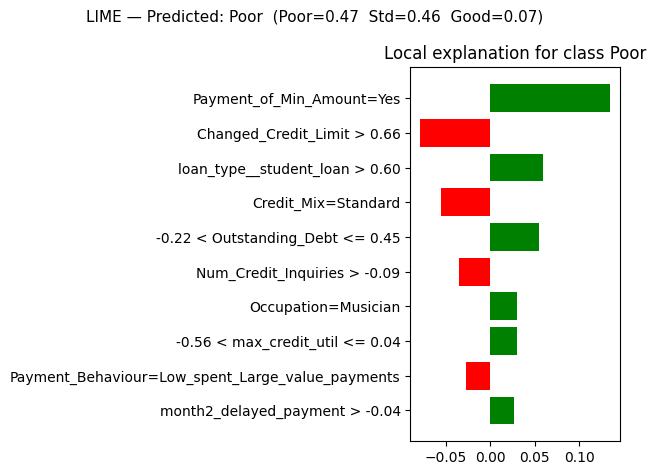

In [50]:
# For tabular or text explanations
import matplotlib.pyplot as plt

fig = lime_exp.as_pyplot_figure(label=pred_class)
fig.suptitle(
    f"LIME — Predicted: {['Poor','Standard','Good'][pred_class]}  "
    f"(Poor={probs[0]:.2f}  Std={probs[1]:.2f}  Good={probs[2]:.2f})",
    fontsize=11
)
plt.tight_layout()
plt.savefig("lime_explanation.png", dpi=150, bbox_inches="tight")
plt.show()

In [51]:
probs

array([0.46681684, 0.45819265, 0.0749905 ], dtype=float32)

## LSTM Classifier

In [55]:
class LSTMClassifier(nn.Module):
    def __init__(self, cat_dims, num_cols, hidden = [128, 64, 32], dropout = 0.3):
        super(LSTMClassifier, self).__init__()
        self.n_cat = len(cat_dims)
        self.embs = nn.ModuleList([nn.Embedding(v, d) for v, d in cat_dims])
        self.lstm = nn.LSTM(
            input_size =sum(d for _, d in cat_dims) + len(num_cols), 
            hidden_size=hidden[0], batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden[0], hidden[1])
        self.net = nn.Sequential(
            self.dropout,
            self.fc,
            nn.BatchNorm1d(hidden[1]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden[1], hidden[2]),
            nn.BatchNorm1d(hidden[2]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden[2], 3)
        )
        
        
    def forward(self, x):                             # single tensor in, no wrapper needed
        cx = x[:, :self.n_cat].long()
        nx = x[:, self.n_cat:].float()
        embedded = torch.cat([e(cx[:, i]) for i, e in enumerate(self.embs)] + [nx], dim=1)
        embedded = embedded.unsqueeze(1)
        lstm_out, _ = self.lstm(embedded)
        return self.net(lstm_out[:, -1, :])

In [56]:
lstm_clf = LSTMClassifier(cat_dims=cat_dims, num_cols=num_cols, hidden=[128, 64, 32], dropout=0.3)
lstm_clf.to(device)
print(f"Parameters : {sum(p.numel() for p in lstm_clf.parameters()):,}")
print(f"Cat embeds : {list(zip(cat_cols, [d for _, d in cat_dims]))}")

Parameters : 107,617
Cat embeds : [('Occupation', 8), ('Credit_Mix', 3), ('Payment_of_Min_Amount', 3), ('Payment_Behaviour', 5)]


In [57]:
optimizer_lstm = torch.optim.AdamW(lstm_clf.parameters(), lr=0.001)
scheduler_lstm = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_lstm, patience=20, factor=0.5)
lstm_train_result = train_dl(lstm_clf, train_loader, val_loader, criterion,
                              optimizer_lstm, scheduler_lstm, device)

Epoch  30  loss: 0.8269  val AUC: 0.7424
Epoch  60  loss: 0.7896  val AUC: 0.7369
Early stopping at epoch 69  |  Best Val AUC: 0.7435


In [58]:
lstm_eval_result = evaluate_dl(lstm_clf, val_loader, device)    

Validation AUC: 0.7435
Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.67      0.59       901
           1       0.71      0.43      0.54      1621
           2       0.43      0.71      0.54       603

    accuracy                           0.56      3125
   macro avg       0.56      0.61      0.56      3125
weighted avg       0.60      0.56      0.55      3125

Confusion Matrix:
[[602 156 143]
 [487 705 429]
 [ 34 138 431]]


In [59]:
lstm_eval_result

(0.7434527352605405,
 tensor([[ 2.1601,  0.4736, -3.4076],
         [ 0.4363,  0.4251, -1.8507],
         [ 1.0107,  0.3011, -1.9835],
         ...,
         [ 2.1203,  0.2665, -2.9526],
         [-0.7136,  0.2206,  0.8943],
         [-0.6288,  0.5037,  0.0450]]),
 tensor([0, 1, 1,  ..., 0, 1, 1]))

In [ ]:
import shap
# import torch
# import numpy as np

# Background & test tensors 
X_train_cat = torch.tensor(X_train[cat_cols].values, dtype=torch.float32)
X_train_num = torch.tensor(X_train[num_cols].values, dtype=torch.float32)
X_train_combined = torch.cat([X_train_cat, X_train_num], dim=1)

X_test_cat  = torch.tensor(X_test[cat_cols].values,  dtype=torch.float32)
X_test_num  = torch.tensor(X_test[num_cols].values,  dtype=torch.float32)
X_test_combined = torch.cat([X_test_cat, X_test_num], dim=1)

bg_idx     = np.random.choice(len(X_train_combined), size=200, replace=False)
background = X_train_combined[bg_idx].to(device)

# GradientExplainer 
lstm_clf.eval()
explainer   = shap.GradientExplainer(lstm_clf, background)


In [64]:
# Correct extraction — sv is (n_samples, n_features, n_classes)
batch_size = 256
all_sv = []

X_test_gpu = X_test_combined.to(device)

for start in range(0, len(X_test_gpu), batch_size):
    batch = X_test_gpu[start : start + batch_size]
    sv    = explainer.shap_values(batch)          # (batch, n_features, n_classes)
    all_sv.append(sv)

shap_array = np.concatenate(all_sv, axis=0)       # (n_samples, n_features, n_classes)
print(f"shap_array shape: {shap_array.shape}")    # (572, 44, 3)

# Split into per-class list to keep consistent with downstream steps
# shap_values_fixed[c] = (n_samples, n_features)
shap_values_fixed = [shap_array[:, :, c] for c in range(3)]
print(f"Per-class shape: {shap_values_fixed[0].shape}")   # (572, 44)

# Feature importance
feature_names   = cat_cols + num_cols
mean_shap       = np.stack([np.abs(sv) for sv in shap_values_fixed]).mean(axis=0).mean(axis=0)
shap_importance = pd.Series(mean_shap, index=feature_names).sort_values(ascending=False)
print(shap_importance.head(10))

shap_array shape: (3125, 44, 3)
Per-class shape: (3125, 44)
Outstanding_Debt              0.216282
month3_delay_from_due_date    0.111495
Changed_Credit_Limit          0.105837
Delay_from_due_date           0.086378
month2_delay_from_due_date    0.081701
loan_type__student_loan       0.034164
loan_type__personal_loan      0.033785
Credit_History_Age            0.033137
month3_credit_util            0.031029
month3_balance                0.025253
dtype: float64


In [88]:
lstm_eval_result, lstm_logits, lstm_labels = evaluate_dl(lstm_clf, val_loader, device)    

Validation AUC: 0.7435
Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.67      0.59       901
           1       0.71      0.43      0.54      1621
           2       0.43      0.71      0.54       603

    accuracy                           0.56      3125
   macro avg       0.56      0.61      0.56      3125
weighted avg       0.60      0.56      0.55      3125

Confusion Matrix:
[[602 156 143]
 [487 705 429]
 [ 34 138 431]]


In [89]:
lstm_labels

tensor([0, 1, 1,  ..., 0, 1, 1])

In [90]:
lstm_temp_scaler = TemperatureScaler()
# lstm_temp_scaler.to(device)
lstm_temp_scaler.fit(lstm_logits, lstm_labels)

Learned temperature T = 1.0660


TemperatureScaler()

In [ ]:

with torch.no_grad():
    lstm_cal_probs = torch.softmax(
        lstm_temp_scaler(lstm_logits), dim=1
    ).cpu().numpy()

In [92]:
lstm_cal_probs

array([[0.8258164 , 0.169732  , 0.00445164],
       [0.47469538, 0.469754  , 0.05555059],
       [0.6352456 , 0.32646596, 0.03828852],
       ...,
       [0.84440464, 0.1483547 , 0.00724064],
       [0.12623785, 0.30324858, 0.5705136 ],
       [0.17316177, 0.5010273 , 0.32581085]],
      shape=(3125, 3), dtype=float32)

In [93]:
lstm_labels = lstm_labels.numpy()
lstm_labels

array([0, 1, 1, ..., 0, 1, 1], shape=(3125,))

In [95]:
def build_risk_score(cal_probs, shap_values, feature_names,
                     tfidf_prefix="loan_type__", n_top=7):
    """
    Parameters
    ----------
    cal_probs     : np.ndarray (n, 3) — [P(Poor), P(Standard), P(Good)]
    shap_values   : list of 3 (n, f) arrays — one per class [Poor, Standard, Good]
    feature_names : list of str
    tfidf_prefix  : prefix for TF-IDF loan-type columns (collapsed for display)
    n_top         : number of top positive/negative contributors to report per row
    Returns
    -------
    pd.DataFrame with one row per sample
    """
    # ── Risk score: PDO formula ────────────────────────────────────
    PDO        = 50
    BASE_SCORE = 600
    FACTOR     = PDO / np.log(2)        # ≈ 72.13 score points per log-unit of odds
    EPSILON    = 1e-7                   # avoid ln(0)

    p_good    = cal_probs[:, 2] + EPSILON
    p_poor    = cal_probs[:, 0] + EPSILON
    raw_score = BASE_SCORE + FACTOR * np.log(p_good / p_poor)
    raw_score = np.clip(raw_score, 300, 850)

    # ── SHAP → score-point space ──────────────────────────────────────────────
    SHAP_WEIGHTS = np.array([-FACTOR, 0.0, FACTOR])
    sv_stack  = np.stack(shap_values, axis=2)       # (n, f, 3)
    sv_score  = sv_stack @ SHAP_WEIGHTS        # (n, f) — score points per feature

    # ── Aggregate loan_type__ TF-IDF columns → single "Loan_Type" ─────────────
    loan_mask     = np.array([f.startswith(tfidf_prefix) for f in feature_names])
    other_names   = [f for f, m in zip(feature_names, loan_mask) if not m]
    sv_other      = sv_score[:, ~loan_mask]
    sv_loan       = sv_score[:, loan_mask].sum(axis=1, keepdims=True)
    display_names = other_names + (["Loan_Type"] if loan_mask.any() else [])
    sv_display    = np.concatenate([sv_other, sv_loan], axis=1)

    shap_df = pd.DataFrame(sv_display, columns=[f"shap_{f}" for f in display_names])

    # ── Top n_top contributors per row ────────────────────────────────────────
    def top_contributors(row):
        sorted_idx = np.argsort(row.values)
        top_neg = [(display_names[i], round(float(row.iloc[i]), 1))
                   for i in sorted_idx[:n_top] if row.iloc[i] < 0]
        top_pos = [(display_names[i], round(float(row.iloc[i]), 1))
                   for i in sorted_idx[-n_top:][::-1] if row.iloc[i] > 0]
        return top_pos, top_neg

    pos_contribs, neg_contribs = zip(*[top_contributors(shap_df.iloc[i])
                                       for i in range(len(shap_df))])

    # ── Risk band (anchored to E[class] values) ───────────────────────────────
    def score_to_band(s):
        if s >= 650: return "Excellent"
        if s >= 600: return "Good"
        if s >= 550: return "Fair"       # E[class] = 0.5
        return "Poor"

    result = pd.DataFrame({
        "p_poor":                cal_probs[:, 0].round(4),
        "p_standard":            cal_probs[:, 1].round(4),
        "p_good":                cal_probs[:, 2].round(4),
        "risk_score":            raw_score.round(0).astype(int),
        "risk_band":             [score_to_band(s) for s in raw_score],
        "top_positive_factors":  [str(c) for c in pos_contribs],
        "top_negative_factors":  [str(c) for c in neg_contribs],
    })

    return pd.concat([result, shap_df], axis=1)

In [96]:
scorecard_df = build_risk_score(lstm_cal_probs, shap_values_fixed, feature_names)
print(scorecard_df[["risk_score", "risk_band", "top_positive_factors", "top_negative_factors"]].head())

   risk_score  risk_band                               top_positive_factors  \
0         300       Poor  [('Loan_Type', 67.1), ('Credit_Utilization_Rat...   
1         445       Poor  [('month3_delay_from_due_date', 14.8), ('balan...   
2         397       Poor  [('Monthly_Balance', 2.6), ('max_credit_util',...   
3         395       Poor  [('Changed_Credit_Limit', 41.8), ('month3_cred...   
4         656  Excellent  [('Outstanding_Debt', 32.0), ('Loan_Type', 11....   

                                top_negative_factors  
0  [('month3_delay_from_due_date', -85.0), ('Chan...  
1  [('Credit_History_Age', -14.4), ('Changed_Cred...  
2  [('Outstanding_Debt', -51.4), ('Loan_Type', -2...  
3  [('month3_delay_from_due_date', -69.9), ('Dela...  
4  [('Credit_History_Age', -13.5), ('Num_Credit_C...  


In [97]:
scorecard_df.head(20)

,p_poor,p_standard,p_good,risk_score,risk_band,top_positive_factors,top_negative_factors,shap_Occupation,shap_Credit_Mix,shap_Payment_of_Min_Amount,...,shap_month3_balance,shap_month3_credit_util,shap_month3_delayed_payment,shap_month3_delay_from_due_date,shap_max_delayed_payment,shap_max_credit_util,shap_credit_util_var,shap_balance_m1_m2,shap_balance_m2_m3,shap_Loan_Type
0,0.8258,0.1697,0.0045,300,Poor,"[('Loan_Type', 67.1), ('Credit_Utilization_Rat...","[('month3_delay_from_due_date', -85.0), ('Chan...",0.0,0.0,0.0,...,-3.336674,-17.151034,-0.408909,-84.955925,0.297420,2.973420,7.523971,1.805601,0.0,67.132373
1,0.4747,0.4698,0.0556,445,Poor,"[('month3_delay_from_due_date', 14.8), ('balan...","[('Credit_History_Age', -14.4), ('Changed_Cred...",0.0,0.0,0.0,...,-5.126231,2.505012,0.923068,14.847677,0.274945,0.890847,-4.232296,14.485476,0.0,9.336861
2,0.6352,0.3265,0.0383,397,Poor,"[('Monthly_Balance', 2.6), ('max_credit_util',...","[('Outstanding_Debt', -51.4), ('Loan_Type', -2...",0.0,0.0,0.0,...,-5.324463,-4.534262,-0.056092,-3.038949,0.130272,0.420202,-0.391131,-0.037363,0.0,-24.285335
3,0.6641,0.2972,0.0386,395,Poor,"[('Changed_Credit_Limit', 41.8), ('month3_cred...","[('month3_delay_from_due_date', -69.9), ('Dela...",0.0,0.0,0.0,...,0.782390,9.913826,-0.332924,-69.911849,-0.198973,-0.528371,-0.341775,4.765161,0.0,9.094532
4,0.1559,0.5057,0.3384,656,Excellent,"[('Outstanding_Debt', 32.0), ('Loan_Type', 11....","[('Credit_History_Age', -13.5), ('Num_Credit_C...",0.0,0.0,0.0,...,4.648156,-1.130288,0.210158,7.818179,-0.115559,0.313882,-1.062597,0.000000,0.0,11.450394
5,0.7873,0.2046,0.0080,300,Poor,"[('month3_credit_util', 16.8), ('balance_m1_m2...","[('month3_delay_from_due_date', -71.1), ('Outs...",0.0,0.0,0.0,...,-1.954324,16.770952,-0.305623,-71.078989,0.073537,0.073284,-0.105256,9.080530,0.0,-17.057587
6,0.2963,0.5751,0.1286,540,Poor,"[('Outstanding_Debt', 65.6), ('month3_delay_fr...","[('Loan_Type', -21.7), ('Changed_Credit_Limit'...",0.0,0.0,0.0,...,-3.223241,6.934396,0.681239,16.778646,0.466617,1.345003,1.090475,4.883262,0.0,-21.654955
7,0.1162,0.2401,0.6438,724,Excellent,"[('month3_delay_from_due_date', 37.6), ('Delay...","[('Changed_Credit_Limit', -7.4), ('month3_cred...",0.0,0.0,0.0,...,-0.647376,-5.161494,0.731351,37.614881,-0.291289,-0.572692,-0.347626,-0.399660,0.0,14.439107
8,0.1742,0.4639,0.3619,653,Excellent,"[('month3_balance', 36.8), ('Loan_Type', 15.4)...","[('month2_credit_util', -12.8), ('month3_credi...",0.0,0.0,0.0,...,36.765699,-7.551294,0.890373,-0.182509,-0.052745,-1.674307,-0.030433,0.000000,0.0,15.421730
9,0.4447,0.3951,0.1602,526,Poor,"[('Changed_Credit_Limit', 109.3), ('month3_cre...","[('Outstanding_Debt', -48.9), ('month3_delay_f...",0.0,0.0,0.0,...,-3.602863,14.675874,0.529749,-30.252453,0.040936,2.502732,0.313929,0.878640,0.0,-18.059108


In [98]:
scorecard_df['risk_score'].median()

np.float64(626.0)

In [99]:
import joblib
import os

os.makedirs("artefacts", exist_ok=True)

# Model weights
torch.save(lstm_clf.state_dict(),   "artefacts/lstm_clf.pt")
torch.save(lstm_temp_scaler.state_dict(),"artefacts/lstm_temp_scaler.pt")

# Preprocessors
joblib.dump(scaler,   "artefacts/scaler.pkl")
joblib.dump(le_dict,  "artefacts/le_dict.pkl")

# SHAP explainer background (needed to re-init DeepExplainer)
np.save("artefacts/shap_background.npy", background.cpu().numpy())

# Save cat_dims and column lists (needed to rebuild model)
import json
meta = {
    "cat_cols": cat_cols,
    "num_cols": num_cols,
    "cat_dims": cat_dims,   # list of [vocab_size, emb_dim] pairs
}
meta["tfidf_prefix"] = "loan_type__"   # add this before json.dump(meta, f)
with open("artefacts/meta.json", "w") as f:
    json.dump(meta, f)

print("Artefacts saved.")

Artefacts saved.
